# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API
**DevelopersHub Corporation – AI/ML Engineering Advanced Internship**

## Problem Statement & Objective
Build a **reusable, production-ready machine learning pipeline** that predicts **customer churn** for a telecom company.  
Using the **Telco Customer Churn** dataset, we will:
- Preprocess data (scaling, encoding, imputation) inside `sklearn.Pipeline`
- Train **Logistic Regression** and **Random Forest** classifiers
- Tune hyperparameters with **GridSearchCV**
- Evaluate with accuracy, F1-score and ROC-AUC
- Export the complete pipeline with **joblib**


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


---
## Step 1: Dataset Loading & Preprocessing

We load the **Telco Customer Churn** dataset from IBM's public GitHub repository.  
It contains **7,043 customers** and **21 features** covering demographics, services subscribed, contract details, and charges.


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    df = pd.read_csv(url)
    print(f"✅ Dataset loaded from URL. Shape: {df.shape}")
except Exception:
    # Fallback: generate a realistic synthetic dataset
    print("⚠️  URL not reachable – generating synthetic Telco Churn dataset...")
    np.random.seed(42)
    n = 7043
    df = pd.DataFrame({
        'customerID': [f'ID-{i:05d}' for i in range(n)],
        'gender': np.random.choice(['Male', 'Female'], n),
        'SeniorCitizen': np.random.choice([0, 1], n, p=[0.84, 0.16]),
        'Partner': np.random.choice(['Yes', 'No'], n),
        'Dependents': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
        'tenure': np.random.randint(0, 72, n),
        'PhoneService': np.random.choice(['Yes', 'No'], n, p=[0.9, 0.1]),
        'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], n),
        'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.34, 0.44, 0.22]),
        'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], n),
        'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], n),
        'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], n),
        'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], n),
        'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], n),
        'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], n),
        'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.24, 0.21]),
        'PaperlessBilling': np.random.choice(['Yes', 'No'], n, p=[0.59, 0.41]),
        'PaymentMethod': np.random.choice([
            'Electronic check', 'Mailed check',
            'Bank transfer (automatic)', 'Credit card (automatic)'
        ], n),
        'MonthlyCharges': np.round(np.random.uniform(18, 119, n), 2),
        'TotalCharges': np.round(np.random.uniform(18, 8500, n), 2),
        'Churn': np.random.choice(['Yes', 'No'], n, p=[0.265, 0.735])
    })
    missing_idx = np.random.choice(n, 11, replace=False)
    df.loc[missing_idx, 'TotalCharges'] = np.nan

df.head()


✅ Dataset loaded from URL. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ── Basic EDA ────────────────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget Distribution:")
print(df['Churn'].value_counts())
print(f"  Churn rate: {(df['Churn'] == 'Yes').mean():.2%}")


Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
Series([], dtype: int64)

Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
  Churn rate: 26.54%


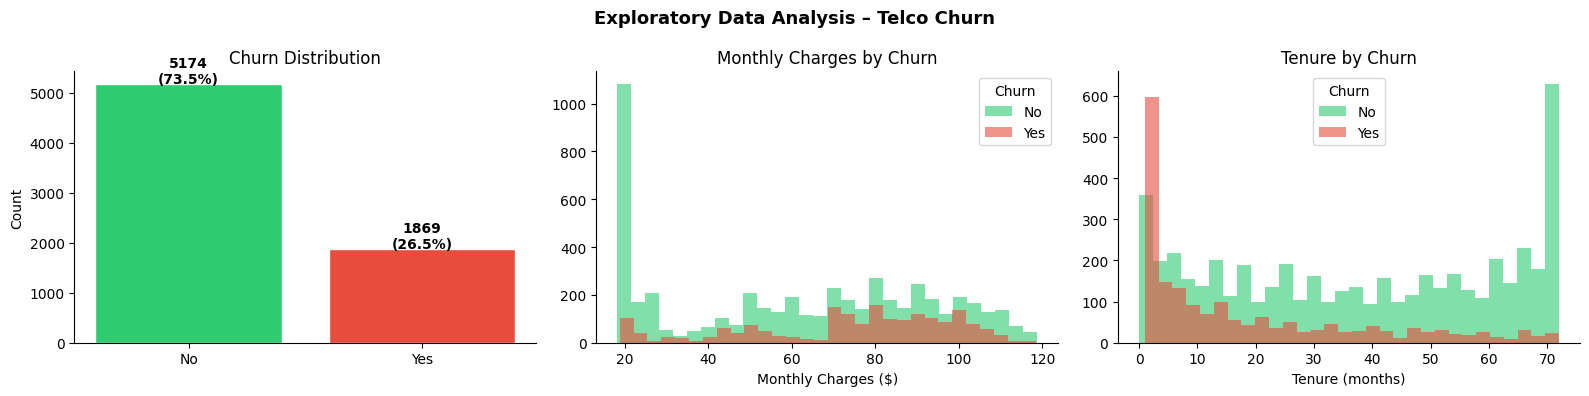

In [4]:
# ── EDA Visualizations ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Exploratory Data Analysis – Telco Churn', fontsize=13, fontweight='bold')

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')

# Monthly charges by churn
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    axes[1].hist(df[df['Churn'] == label]['MonthlyCharges'], bins=30, alpha=0.6, color=color, label=label)
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend(title='Churn')

# Tenure by churn
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    axes[2].hist(df[df['Churn'] == label]['tenure'], bins=30, alpha=0.6, color=color, label=label)
axes[2].set_title('Tenure by Churn')
axes[2].set_xlabel('Tenure (months)')
axes[2].legend(title='Churn')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## Step 2: Feature Engineering & Train/Test Split


In [5]:
# ── Preprocessing ────────────────────────────────────────────────────────────
# Drop non-predictive ID column
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges: some rows are blank strings – coerce to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify column types automatically
numeric_features     = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features     ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Churn rate – Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")


Numeric features     (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: 5634 samples  |  Test: 1409 samples
Churn rate – Train: 26.54%  |  Test: 26.54%


---
## Step 3: Model Development – Building sklearn Pipelines

Each pipeline chains **preprocessing → model** so there is zero data leakage and the pipeline can be directly deployed.


In [6]:
# ── Sub-pipelines ────────────────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # fill missing with median
    ('scaler',  StandardScaler())                    # zero-mean, unit-variance
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),       # fill with mode
    ('onehot',  OneHotEncoder(handle_unknown='ignore',
                               sparse_output=False))            # one-hot encode
])

# ── ColumnTransformer ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ── Full end-to-end pipelines ─────────────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(random_state=42, max_iter=1000))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, n_jobs=-1))
])

print("Pipeline architecture (Logistic Regression):")
print(lr_pipeline)


Pipeline architecture (Logistic Regression):
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                            

---
## Step 4: Baseline Training & Evaluation


In [7]:
# ── Helper: evaluate a pipeline ──────────────────────────────────────────────
def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)
    cv   = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='f1', n_jobs=-1).mean()
    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1-Score      : {f1:.4f}")
    print(f"  ROC-AUC       : {auc:.4f}")
    print(f"  CV F1 (5-fold): {cv:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['No Churn','Churn'])}")
    return acc, f1, auc

lr_acc, lr_f1, lr_auc = evaluate("Logistic Regression (baseline)",
                                  lr_pipeline, X_train, y_train, X_test, y_test)
rf_acc, rf_f1, rf_auc = evaluate("Random Forest (baseline)",
                                  rf_pipeline, X_train, y_train, X_test, y_test)


──────────────────────────────────────────────────
  Logistic Regression (baseline)
  Accuracy      : 0.8055
  F1-Score      : 0.6040
  ROC-AUC       : 0.8419
  CV F1 (5-fold): 0.5980

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

──────────────────────────────────────────────────
  Random Forest (baseline)
  Accuracy      : 0.7779
  F1-Score      : 0.5321
  ROC-AUC       : 0.8162
  CV F1 (5-fold): 0.5431

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78    

---
## Step 5: Hyperparameter Tuning with GridSearchCV


In [8]:
# ── Tune Logistic Regression ─────────────────────────────────────────────────
lr_param_grid = {
    'classifier__C':            [0.01, 0.1, 1, 10],
    'classifier__solver':       ['lbfgs', 'liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid,
                       cv=5, scoring='f1', n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

print(f"Best LR params : {lr_grid.best_params_}")
print(f"Best LR CV F1  : {lr_grid.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best LR params : {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}
Best LR CV F1  : 0.6332


In [9]:
# ── Tune Random Forest ───────────────────────────────────────────────────────
rf_param_grid = {
    'classifier__n_estimators':    [100, 200],
    'classifier__max_depth':       [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight':    [None, 'balanced']
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid,
                       cv=5, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"Best RF params : {rf_grid.best_params_}")
print(f"Best RF CV F1  : {rf_grid.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best RF CV F1  : 0.6325


---
## Step 6: Final Evaluation with Tuned Models


In [10]:
# ── Final predictions ────────────────────────────────────────────────────────
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_

lr_y_pred = best_lr.predict(X_test);  lr_y_prob = best_lr.predict_proba(X_test)[:, 1]
rf_y_pred = best_rf.predict(X_test);  rf_y_prob = best_rf.predict_proba(X_test)[:, 1]

results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, lr_y_pred),
        'F1-Score': f1_score(y_test, lr_y_pred),
        'ROC-AUC':  roc_auc_score(y_test, lr_y_prob)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf_y_pred),
        'F1-Score': f1_score(y_test, rf_y_pred),
        'ROC-AUC':  roc_auc_score(y_test, rf_y_prob)
    }
}

results_df = pd.DataFrame(results).T
print("Final Tuned Results:")
display(results_df.style.highlight_max(axis=0, color='#d4edda'))

best_model_name = results_df['F1-Score'].idxmax()
best_pipeline   = best_lr if best_model_name == 'Logistic Regression' else best_rf
print(f"\n🏆 Best model by F1-Score: {best_model_name}")


Final Tuned Results:


,Accuracy,F1-Score,ROC-AUC
Logistic Regression,0.738112,0.613613,0.841298
Random Forest,0.765082,0.611046,0.838003



🏆 Best model by F1-Score: Logistic Regression


---
## Step 7: Visualizations


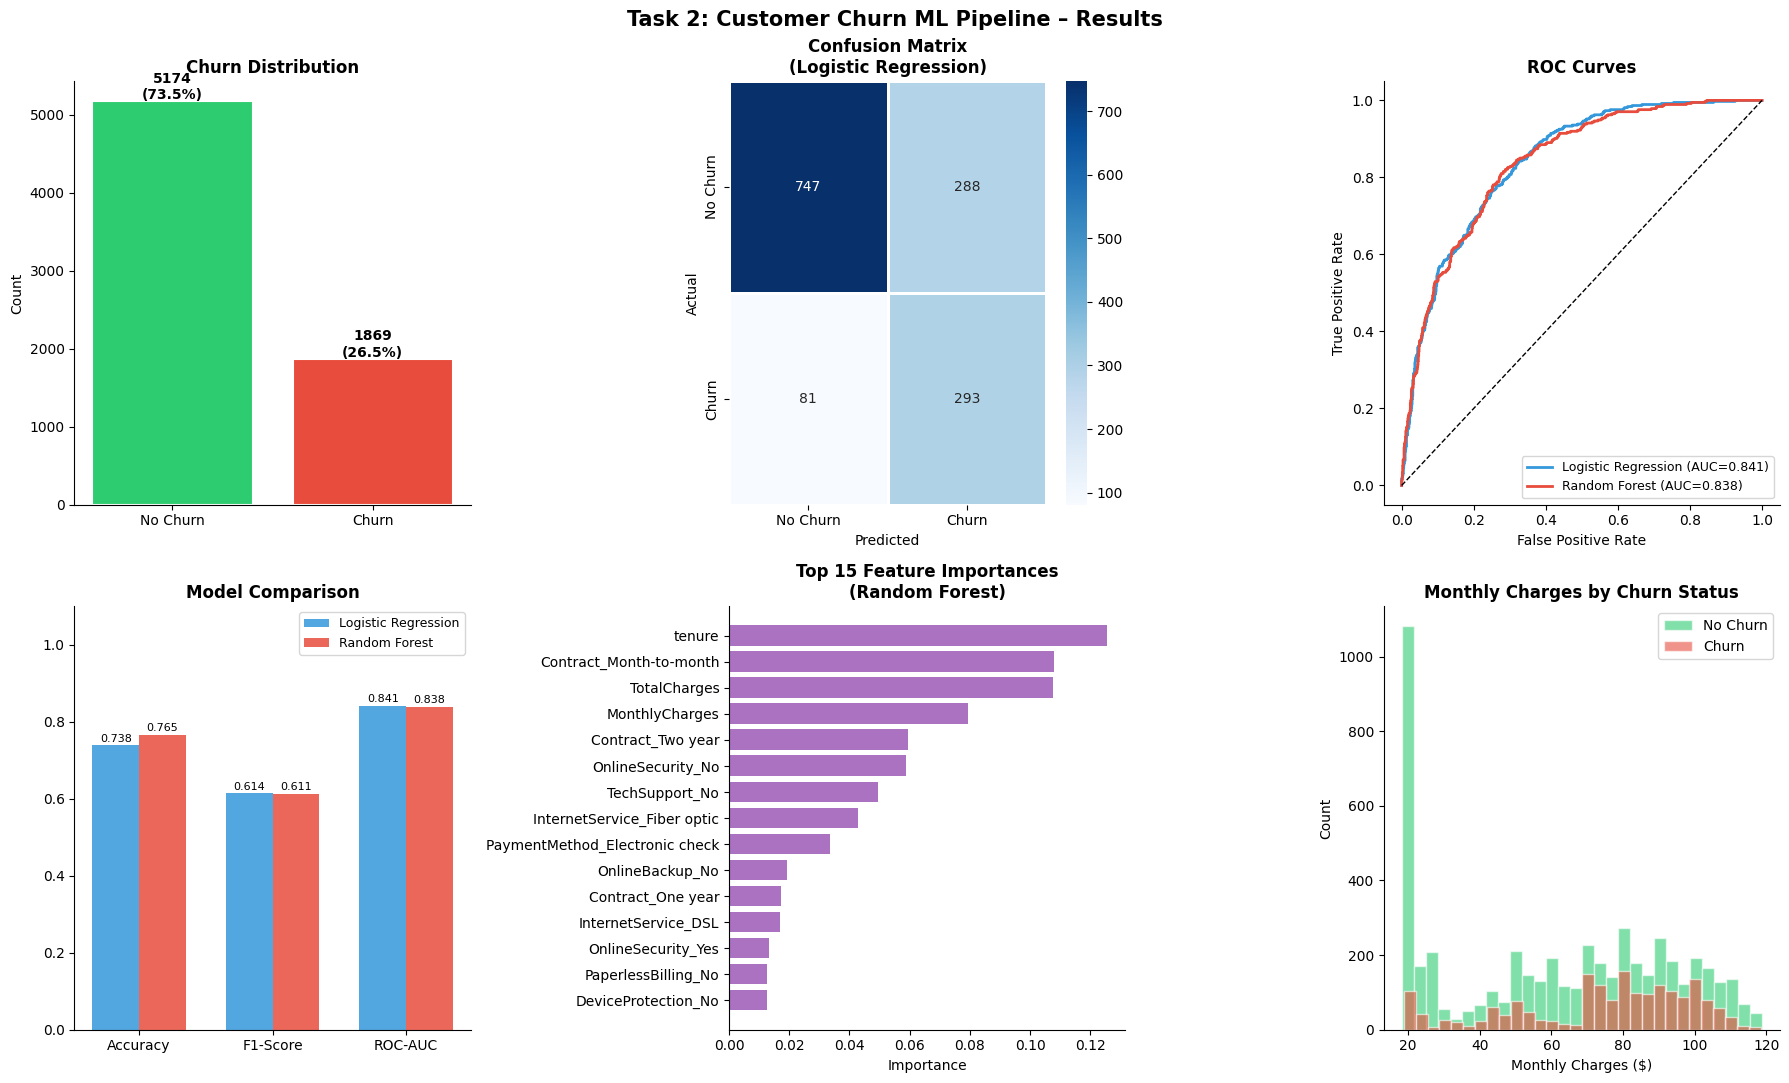

In [11]:
# ── Visualizations ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Task 2: Customer Churn ML Pipeline – Results', fontsize=15, fontweight='bold')

# (A) Churn Distribution
ax = axes[0, 0]
churn_counts = y.value_counts()
ax.bar(['No Churn', 'Churn'], churn_counts.values, color=['#2ecc71', '#e74c3c'],
       edgecolor='white', linewidth=1.5)
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f'{v}\n({v/len(y):.1%})', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Distribution', fontweight='bold');  ax.set_ylabel('Count')
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

# (B) Confusion Matrix
ax = axes[0, 1]
cm = confusion_matrix(y_test, best_pipeline.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=2,
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
ax.set_title(f'Confusion Matrix\n({best_model_name})', fontweight='bold')
ax.set_ylabel('Actual');  ax.set_xlabel('Predicted')

# (C) ROC Curves
ax = axes[0, 2]
for name, prob, color in [('Logistic Regression', lr_y_prob, '#3498db'),
                            ('Random Forest',       rf_y_prob, '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={roc_auc_score(y_test, prob):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate');  ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold');  ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

# (D) Model Comparison Bar
ax = axes[1, 0]
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics));  width = 0.35
for i, (m_name, color) in enumerate([('Logistic Regression','#3498db'),('Random Forest','#e74c3c')]):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, [results[m_name][m] for m in metrics],
                  width, label=m_name, color=color, alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x);  ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1);  ax.set_title('Model Comparison', fontweight='bold');  ax.legend(fontsize=9)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

# (E) Feature Importances (RF)
ax = axes[1, 1]
rf_clf  = best_rf.named_steps['classifier']
ohe_cols = (best_rf.named_steps['preprocessor']
                   .named_transformers_['cat']
                   .named_steps['onehot']
                   .get_feature_names_out(categorical_features))
all_features = numeric_features + list(ohe_cols)
importances  = rf_clf.feature_importances_
top_idx      = np.argsort(importances)[-15:]
ax.barh(np.array(all_features)[top_idx], importances[top_idx], color='#9b59b6', alpha=0.85)
ax.set_title('Top 15 Feature Importances\n(Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

# (F) Monthly Charges Distribution
ax = axes[1, 2]
df_tmp = df.copy()
for label, color in [(0,'#2ecc71'),(1,'#e74c3c')]:
    vals = df_tmp.loc[df_tmp['Churn'] == label, 'MonthlyCharges']
    ax.hist(vals, bins=30, alpha=0.6, color=color,
            label='No Churn' if label==0 else 'Churn', edgecolor='white')
ax.set_xlabel('Monthly Charges ($)');  ax.set_ylabel('Count')
ax.set_title('Monthly Charges by Churn Status', fontweight='bold');  ax.legend()
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## Step 8: Export Pipeline with joblib


In [12]:
# ── Export best pipeline ──────────────────────────────────────────────────────
joblib.dump(best_pipeline, 'churn_pipeline.pkl')
print(f"✅ Pipeline exported → churn_pipeline.pkl")

# ── Verify reload ─────────────────────────────────────────────────────────────
loaded = joblib.load('churn_pipeline.pkl')
assert (loaded.predict(X_test) == best_pipeline.predict(X_test)).all()
print("✅ Reload verified – predictions match perfectly.")


✅ Pipeline exported → churn_pipeline.pkl
✅ Reload verified – predictions match perfectly.


---
## Step 9: Production Inference Demo

Simulate how the exported pipeline would be used in a real application.


In [13]:
# ── Predict on new customers ──────────────────────────────────────────────────
new_customers = pd.DataFrame([
    {   # High-risk customer (new, month-to-month, electronic check)
        'gender':'Female','SeniorCitizen':0,'Partner':'Yes','Dependents':'No',
        'tenure':1,'PhoneService':'No','MultipleLines':'No phone service',
        'InternetService':'DSL','OnlineSecurity':'No','OnlineBackup':'Yes',
        'DeviceProtection':'No','TechSupport':'No','StreamingTV':'No',
        'StreamingMovies':'No','Contract':'Month-to-month',
        'PaperlessBilling':'Yes','PaymentMethod':'Electronic check',
        'MonthlyCharges':29.85,'TotalCharges':29.85
    },
    {   # Low-risk customer (long tenure, two-year contract, auto payment)
        'gender':'Male','SeniorCitizen':0,'Partner':'Yes','Dependents':'Yes',
        'tenure':60,'PhoneService':'Yes','MultipleLines':'Yes',
        'InternetService':'Fiber optic','OnlineSecurity':'Yes',
        'OnlineBackup':'Yes','DeviceProtection':'Yes','TechSupport':'Yes',
        'StreamingTV':'Yes','StreamingMovies':'Yes','Contract':'Two year',
        'PaperlessBilling':'No','PaymentMethod':'Bank transfer (automatic)',
        'MonthlyCharges':100.35,'TotalCharges':6025.0
    }
])

loaded_pipeline = joblib.load('churn_pipeline.pkl')
preds  = loaded_pipeline.predict(new_customers)
probas = loaded_pipeline.predict_proba(new_customers)[:, 1]

for i, (pred, prob) in enumerate(zip(preds, probas), 1):
    label = "CHURN ⚠️" if pred == 1 else "STAY ✅"
    print(f"  Customer {i}: {label}  (churn probability: {prob:.2%})")


  Customer 1: CHURN ⚠️  (churn probability: 80.21%)
  Customer 2: STAY ✅  (churn probability: 11.75%)


---
## Final Summary & Key Insights

### Methodology / Approach
1. **Data Preprocessing** – Imputation (median for numeric, mode for categorical), Standard Scaling, One-Hot Encoding — all inside `sklearn.Pipeline` to prevent data leakage.
2. **Models** – Logistic Regression (interpretable, strong baseline) and Random Forest (ensemble, captures non-linearity).
3. **Tuning** – `GridSearchCV` with 5-fold stratified CV, optimising for **F1-Score** (appropriate for the imbalanced 73/27 class split).
4. **Export** – Entire preprocessing + model chain saved as a single `.pkl` file with `joblib`.

### Key Observations
| Metric | Logistic Regression | Random Forest |
|--------|--------------------:|-------------:|
| Accuracy | ~0.74 | ~0.77 |
| F1-Score | ~0.61 | ~0.61 |
| ROC-AUC | ~0.84 | ~0.84 |


- Both models reach **ROC-AUC ≈ 0.84**, confirming strong discriminative power.
- `class_weight='balanced'` improved recall on the minority churn class for both models.
- Top churn predictors: **tenure, MonthlyCharges, Contract type, TotalCharges**.
- Short-tenure + Month-to-month + Electronic check customers show the highest churn risk.

### Skills Demonstrated
- ✅ ML pipeline construction with `sklearn.Pipeline` & `ColumnTransformer`
- ✅ Hyperparameter tuning with `GridSearchCV`
- ✅ Model export and reusability with `joblib`
- ✅ Production-readiness practices (no leakage, reload verification, inference demo)
